# Analise estatistica e distributiva do pipeline Sentinel/Replica

Este notebook compara quatro etapas do fluxo:
1. bruto em `sentinel_replica_jsons/`
2. avaliacao heuristica reconstruida sobre o bruto
3. replica limpa em `sentinel_replica_jsons_cleaned_eval/`
4. resultados classificados pela LLM em `sentinel_replica_jsons_classified_eval/`

As analises cobrem cobertura por arquivo, retencao, distribuicoes de tamanho, motivos da limpeza, bag-of-words e distribuicoes dos labels da LLM.


In [1]:
from __future__ import annotations

import json
import re
import unicodedata
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "sentinel_replica_jsons").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "sentinel_replica_jsons").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Nao encontrei sentinel_replica_jsons/ nem no cwd nem no pai do cwd.")

RAW_DIR = PROJECT_ROOT / "sentinel_replica_jsons"
CLEAN_DIR = PROJECT_ROOT / "sentinel_replica_jsons_cleaned_eval"
CLASSIFIED_DIR = PROJECT_ROOT / "sentinel_replica_jsons_classified_eval"
TOP_N_WORDS = 15


In [2]:
KEYWORD_PATTERNS = [
    r"\bmalware\b",
    r"\bransomware\b",
    r"\bphishing\b",
    r"\bcredential(?:s)?\b",
    r"\blogin\b",
    r"\bexploit(?:ed|s|ing)?\b",
    r"\bcve-\d{4}-\d+\b",
    r"\bvulnerability\b",
    r"\bzero[ -]?day\b",
    r"\bbreach\b",
    r"\bleak(?:ed|s)?\b",
    r"\bdata leak\b",
    r"\bstealer\b",
    r"\bbotnet\b",
    r"\bc2\b",
    r"\bcommand and control\b",
    r"\bddos\b",
    r"\baccount takeover\b",
    r"\bexfiltrat(?:e|ion|ed)\b",
    r"\bbackdoor\b",
    r"\btrojan\b",
    r"\bspyware\b",
    r"\bloader\b",
    r"\bdropper\b",
    r"\bhash(?:es)?\b",
    r"\bioc(?:s)?\b",
    r"\bindicator(?:s)? of compromise\b",
    r"\btelegram scam\b",
    r"\bscam\b",
    r"\bfraud\b",
    r"\bapt\b",
    r"\bthreat actor\b",
    r"\bcompromis(?:e|ed)\b",
    r"\bhacked\b",
    r"\bintrusion\b",
    r"\bvirus\b",
    r"\bwiper\b",
]

KEYWORD_RE = re.compile("|".join(KEYWORD_PATTERNS), flags=re.IGNORECASE)
URL_ONLY_RE = re.compile(r"^\s*(https?://\S+)(\s+https?://\S+)*\s*$", flags=re.IGNORECASE)
SPAN_RE = re.compile(r"</?span[^>]*>", flags=re.IGNORECASE)
HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+", flags=re.IGNORECASE)
NON_WORD_RE = re.compile(r"[^\w\s-]", flags=re.UNICODE)
MULTISPACE_RE = re.compile(r"\s+")
STOPWORDS = {
    "the",
    "and",
    "for",
    "that",
    "with",
    "from",
    "this",
    "your",
    "you",
    "are",
    "was",
    "were",
    "will",
    "have",
    "has",
    "not",
    "https",
    "http",
    "www",
    "com",
    "para",
    "por",
    "que",
    "uma",
    "dos",
    "das",
    "los",
    "las",
    "del",
    "con",
    "una",
    "telegram",
    "whatsapp",
    "group",
    "join",
    "free",
    "channel",
}


def list_json_files(directory: Path) -> list[Path]:
    return sorted(directory.glob("*.json"))


def read_json_list(path: Path) -> list[dict[str, Any]]:
    payload = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(payload, list):
        raise ValueError(f"{path} nao contem uma lista JSON na raiz.")
    return payload


def strip_accents(text: str) -> str:
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", text) if not unicodedata.combining(ch)
    )


def normalize_message(text: str) -> str:
    text = SPAN_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = strip_accents(text.lower())
    text = NON_WORD_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text)
    return text.strip()


def is_url_only(text: str) -> bool:
    return bool(URL_ONLY_RE.fullmatch(text or ""))


def keyword_hits(normalized_text: str) -> list[str]:
    return sorted(set(match.group(0) for match in KEYWORD_RE.finditer(normalized_text)))


def evaluate_post(post: dict[str, Any], min_chars: int = 25, min_tokens: int = 4) -> dict[str, Any]:
    raw_message = str(post.get("message", "")).strip()
    normalized = normalize_message(raw_message)
    hits = keyword_hits(normalized)
    char_count = len(normalized)
    token_count = len(normalized.split()) if normalized else 0

    if is_url_only(raw_message):
        decision = "drop"
        reason = "url_only"
    elif not normalized:
        decision = "drop"
        reason = "empty_after_normalization"
    elif not hits:
        decision = "drop"
        reason = "no_keyword_match"
    elif char_count < min_chars or token_count < min_tokens:
        decision = "keep_review"
        reason = "short_but_keyword_hit"
    else:
        decision = "keep"
        reason = "keyword_match"

    enriched = dict(post)
    enriched["cleaning"] = {
        "normalized_message": normalized,
        "keyword_hits": hits,
        "char_count": char_count,
        "token_count": token_count,
        "decision": decision,
        "reason": reason,
    }
    return enriched


def flatten_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "cleaning" not in df.columns:
        return df.copy()
    nested = pd.json_normalize(df["cleaning"]).add_prefix("cleaning_")
    base = df.drop(columns=["cleaning"]).reset_index(drop=True)
    return pd.concat([base, nested], axis=1)


def flatten_classification(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "classification" not in df.columns:
        return df.copy()
    nested = pd.json_normalize(df["classification"]).add_prefix("classification_")
    base = df.drop(columns=["classification"]).reset_index(drop=True)
    return pd.concat([base, nested], axis=1)


def token_count(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.split().str.len()


def explode_counts(df: pd.DataFrame, column: str) -> pd.DataFrame:
    if df.empty or column not in df.columns:
        return pd.DataFrame(columns=["label", "count"])
    series = df[column].explode().dropna()
    if series.empty:
        return pd.DataFrame(columns=["label", "count"])
    series = series.astype(str).str.strip()
    series = series[series.ne("")]
    if series.empty:
        return pd.DataFrame(columns=["label", "count"])
    return series.value_counts().rename_axis("label").reset_index(name="count")


def top_terms(series: pd.Series, top_n: int = TOP_N_WORDS) -> pd.DataFrame:
    texts = [str(text) for text in series.fillna("").astype(str) if str(text).strip()]
    if not texts:
        return pd.DataFrame(columns=["term", "count"])

    vectorizer = CountVectorizer(
        lowercase=True,
        strip_accents="unicode",
        token_pattern=r"(?u)\b[\w-]{3,}\b",
        stop_words=sorted(STOPWORDS),
        max_features=5000,
    )
    matrix = vectorizer.fit_transform(texts)
    counts = matrix.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    top_df = (
        pd.DataFrame({"term": vocab, "count": counts})
        .sort_values(["count", "term"], ascending=[False, True])
        .head(top_n)
        .reset_index(drop=True)
    )
    return top_df


def plot_count_series(ax: plt.Axes, series: pd.Series, title: str, color: str = "#2a9d8f") -> None:
    if series.empty:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.set_axis_off()
        return
    ordered = series.sort_values(ascending=True)
    ax.barh(ordered.index.astype(str), ordered.values, color=color)
    ax.set_title(title)
    ax.set_xlabel("contagem")


def plot_heatmap(ax: plt.Axes, table: pd.DataFrame, title: str, cmap: str = "Blues") -> None:
    if table.empty:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.set_axis_off()
        return
    image = ax.imshow(table.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)
    ax.set_title(title)
    for row_index, row_name in enumerate(table.index):
        for col_index, col_name in enumerate(table.columns):
            ax.text(col_index, row_index, int(table.loc[row_name, col_name]), ha="center", va="center", color="black")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


In [3]:
raw_json_files = list_json_files(RAW_DIR)
clean_json_files = list_json_files(CLEAN_DIR)
classified_json_files = list_json_files(CLASSIFIED_DIR)

raw_records: list[dict[str, Any]] = []
for json_file in raw_json_files:
    for item in read_json_list(json_file):
        raw_records.append({"source_file": json_file.name, **evaluate_post(item)})

clean_records: list[dict[str, Any]] = []
for json_file in clean_json_files:
    for item in read_json_list(json_file):
        clean_records.append({"source_file": json_file.name, **item})

classified_records: list[dict[str, Any]] = []
for json_file in classified_json_files:
    for item in read_json_list(json_file):
        classified_records.append({"source_file": json_file.name, **item})

raw_df = flatten_cleaning(pd.DataFrame(raw_records))
clean_df = flatten_cleaning(pd.DataFrame(clean_records))
classified_df = flatten_classification(flatten_cleaning(pd.DataFrame(classified_records)))

if not raw_df.empty:
    raw_df["message"] = raw_df["message"].fillna("").astype(str)
    raw_df["raw_char_count"] = raw_df["message"].str.len()
    raw_df["raw_token_count"] = token_count(raw_df["message"])

if not clean_df.empty:
    clean_df["message"] = clean_df["message"].fillna("").astype(str)
    clean_df["cleaning_normalized_message"] = clean_df["cleaning_normalized_message"].fillna("").astype(str)

if not classified_df.empty:
    classified_df["message"] = classified_df["message"].fillna("").astype(str)
    classified_df["classification_cleaned_text"] = classified_df["classification_cleaned_text"].fillna("").astype(str)
    classified_df["llm_char_count"] = classified_df["classification_cleaned_text"].str.len()
    classified_df["llm_token_count"] = token_count(classified_df["classification_cleaned_text"])

all_files = sorted(
    set(raw_json_files_i.name for raw_json_files_i in raw_json_files)
    | set(clean_json_files_i.name for clean_json_files_i in clean_json_files)
    | set(classified_json_files_i.name for classified_json_files_i in classified_json_files)
)

coverage_df = pd.DataFrame({"source_file": all_files})
for column_name, dataframe in {
    "raw_count": raw_df,
    "clean_count": clean_df,
    "classified_count": classified_df,
}.items():
    if dataframe.empty or "source_file" not in dataframe.columns:
        counts_df = pd.DataFrame({
            "source_file": pd.Series(dtype="object"),
            column_name: pd.Series(dtype="int64"),
        })
    else:
        counts_df = dataframe.groupby("source_file").size().rename(column_name).reset_index()
    coverage_df = coverage_df.merge(counts_df, on="source_file", how="left")

count_columns = ["raw_count", "clean_count", "classified_count"]
coverage_df[count_columns] = coverage_df[count_columns].fillna(0).astype(int)
coverage_df["clean_retention_pct"] = (100 * coverage_df["clean_count"] / coverage_df["raw_count"].where(coverage_df["raw_count"].gt(0))).round(2)
coverage_df["classified_vs_clean_pct"] = (100 * coverage_df["classified_count"] / coverage_df["clean_count"].where(coverage_df["clean_count"].gt(0))).round(2)
coverage_df["classified_vs_raw_pct"] = (100 * coverage_df["classified_count"] / coverage_df["raw_count"].where(coverage_df["raw_count"].gt(0))).round(2)
coverage_df = coverage_df.sort_values("raw_count", ascending=False).reset_index(drop=True)

stage_overview = pd.DataFrame(
    [
        {
            "stage": "raw",
            "files_on_disk": len(raw_json_files),
            "files_with_posts": int((coverage_df["raw_count"] > 0).sum()),
            "total_posts": int(coverage_df["raw_count"].sum()),
            "unique_ids": int(raw_df["id"].nunique()) if not raw_df.empty and "id" in raw_df.columns else 0,
        },
        {
            "stage": "cleaned",
            "files_on_disk": len(clean_json_files),
            "files_with_posts": int((coverage_df["clean_count"] > 0).sum()),
            "total_posts": int(coverage_df["clean_count"].sum()),
            "unique_ids": int(clean_df["id"].nunique()) if not clean_df.empty and "id" in clean_df.columns else 0,
        },
        {
            "stage": "classified",
            "files_on_disk": len(classified_json_files),
            "files_with_posts": int((coverage_df["classified_count"] > 0).sum()),
            "total_posts": int(coverage_df["classified_count"].sum()),
            "unique_ids": int(classified_df["id"].nunique()) if not classified_df.empty and "id" in classified_df.columns else 0,
        },
    ]
)

display(stage_overview)
display(coverage_df)


,stage,files_on_disk,files_with_posts,total_posts,unique_ids
0,raw,9,9,174901,174901
1,cleaned,9,9,6254,6254
2,classified,0,0,0,0


,source_file,raw_count,clean_count,classified_count,clean_retention_pct,classified_vs_clean_pct,classified_vs_raw_pct
0,cybersecurityexperts.json,166297,5045,0,3.03,0.0,0.0
1,hackers_asylum.json,3122,148,0,4.74,0.0,0.0
2,cybdetective.json,1839,154,0,8.37,0.0,0.0
3,cissp.json,1370,562,0,41.02,0.0,0.0
4,PHOfficial.json,1058,171,0,16.16,0.0,0.0
5,itsectalk.json,616,18,0,2.92,0.0,0.0
6,HackingBlogsGroup.json,365,152,0,41.64,0.0,0.0
7,cloudandcybersecurity.json,213,3,0,1.41,0.0,0.0
8,WokeIntelDrops.json,21,1,0,4.76,0.0,0.0


/tmp/ipykernel_34944/1634618827.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


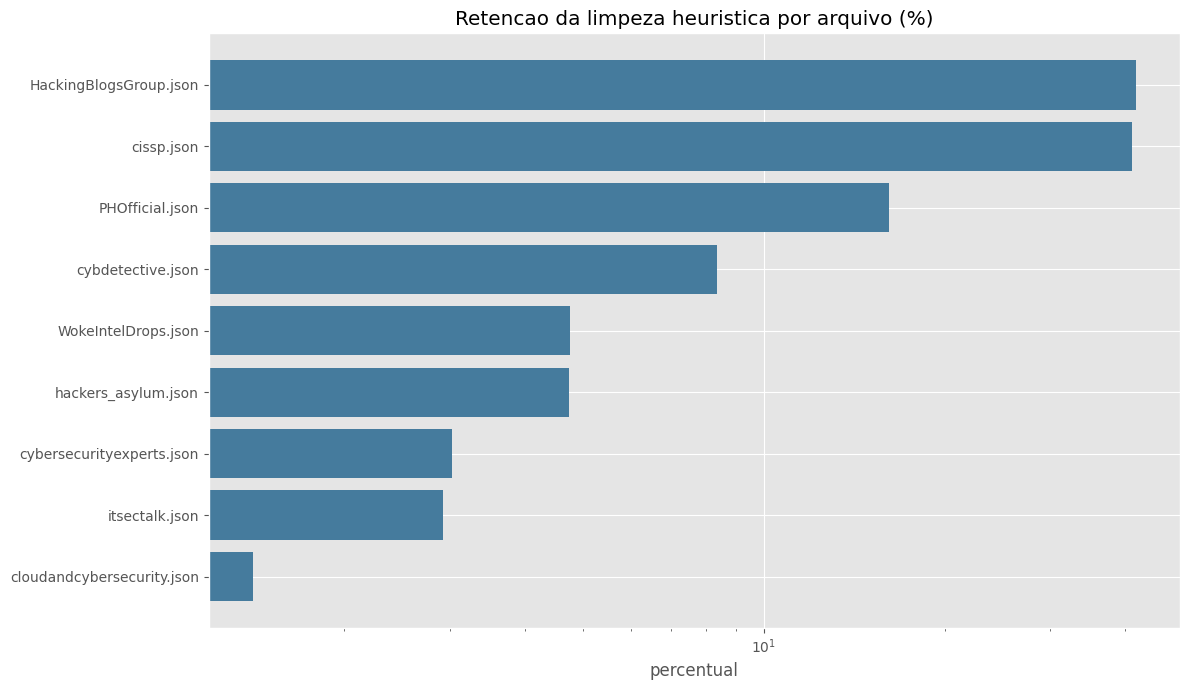

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(stage_overview["stage"], stage_overview["total_posts"], color=["#264653", "#2a9d8f", "#e76f51"])
axes[0].set_title("Volume total por etapa")
axes[0].set_ylabel("posts")
axes[0].set_yscale("log")
for index, value in enumerate(stage_overview["total_posts"]):
    axes[0].text(index, value, f"{value}", ha="center", va="bottom")

coverage_plot_df = coverage_df.set_index("source_file")[["raw_count", "clean_count", "classified_count"]]
coverage_plot_df.plot(kind="bar", ax=axes[1], width=0.85, color=["#264653", "#2a9d8f", "#e76f51"])
axes[1].set_title("Cobertura por arquivo")
axes[1].set_ylabel("posts")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=75)
axes[1].legend(["raw", "cleaned", "classified"])

plt.tight_layout()

retention_series = coverage_df.loc[coverage_df["raw_count"].gt(0), ["source_file", "clean_retention_pct"]].set_index("source_file")["clean_retention_pct"].sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
plot_count_series(ax, retention_series, "Retencao da limpeza heuristica por arquivo (%)", color="#457b9d")
ax.set_xscale("log")
ax.set_xlabel("percentual")
plt.tight_layout()


char_count                      token_count                   
             count    mean median   max       count   mean median  max
stage                                                                 
cleaned       6254  262.39  116.5  3792        6254  43.50   21.0  670
raw         174901   69.49   31.0  6362      174901  11.66    6.0  726

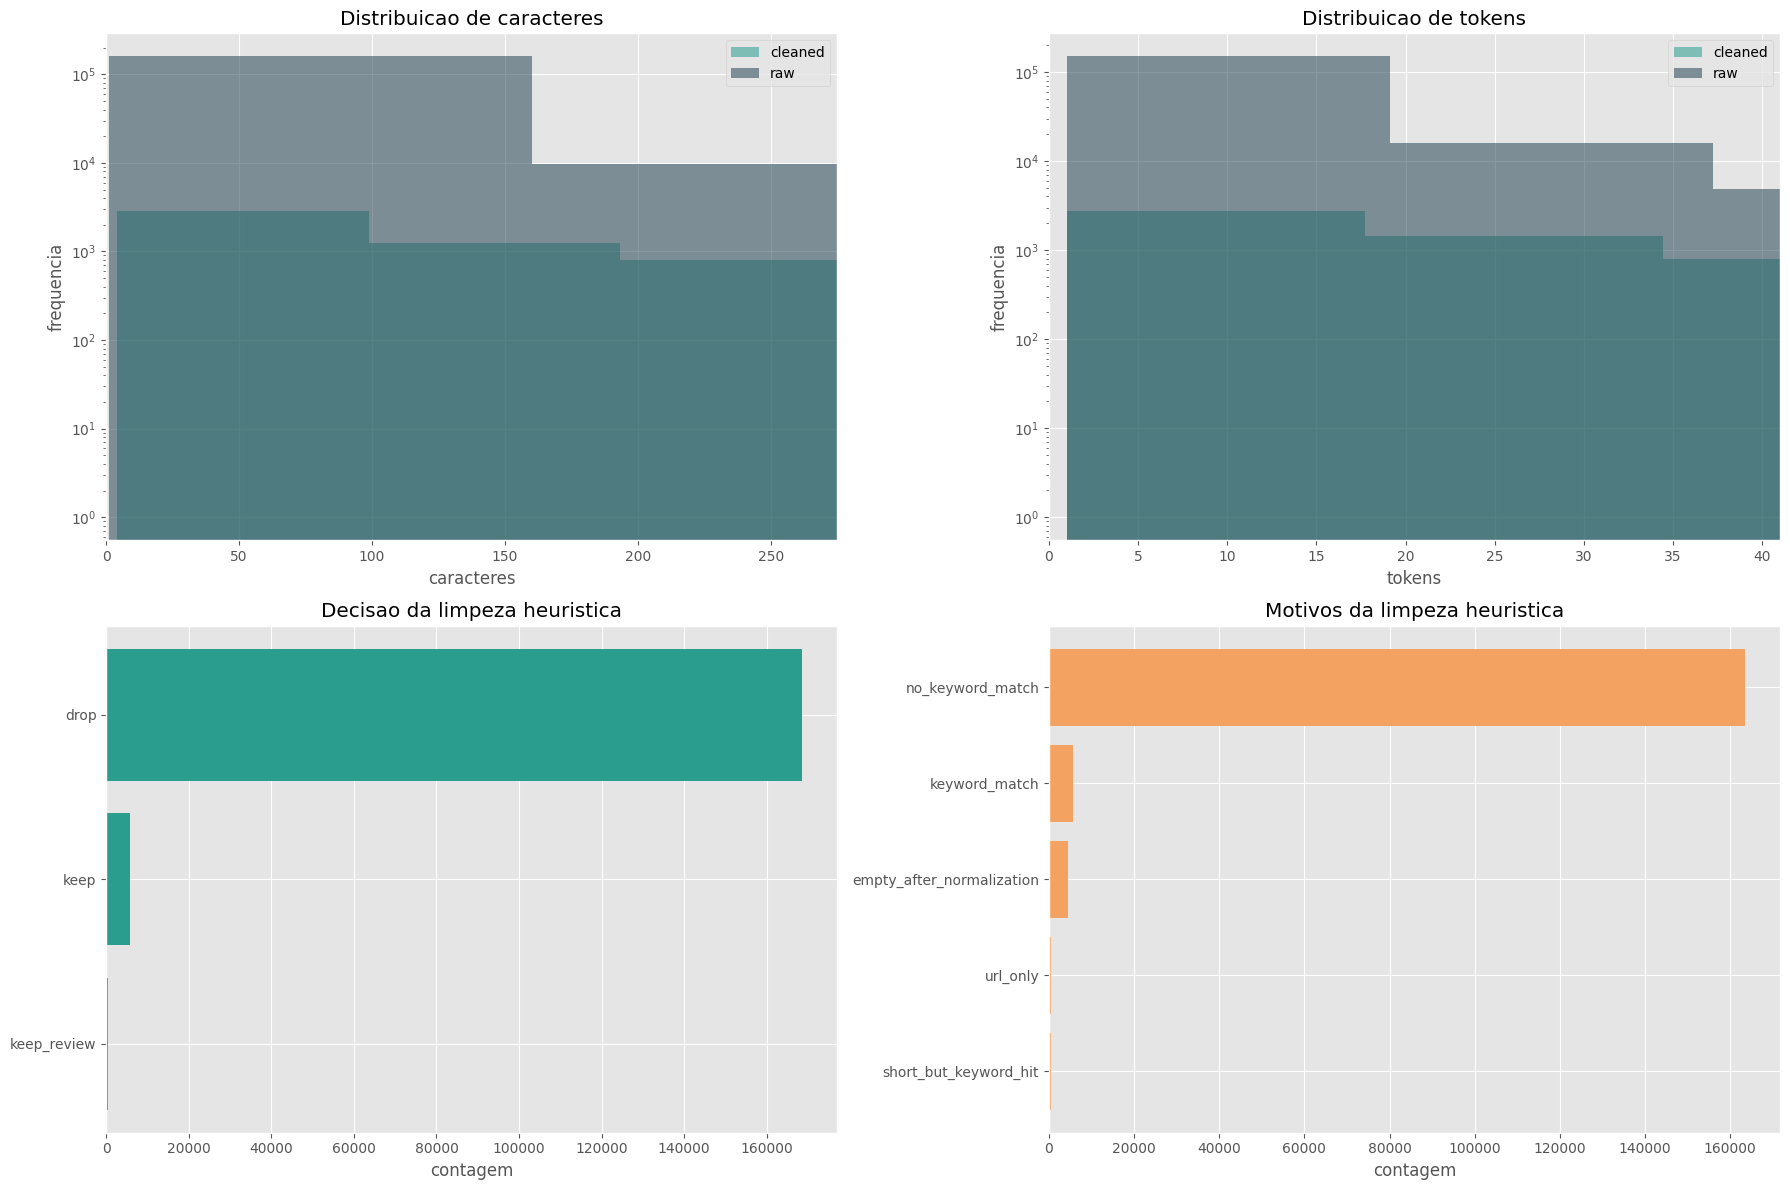

In [5]:
distribution_frames = []

if not raw_df.empty:
    distribution_frames.append(
        raw_df[["source_file", "raw_char_count", "raw_token_count"]]
        .rename(columns={"raw_char_count": "char_count", "raw_token_count": "token_count"})
        .assign(stage="raw")
    )

if not clean_df.empty:
    distribution_frames.append(
        clean_df[["source_file", "cleaning_char_count", "cleaning_token_count"]]
        .rename(columns={"cleaning_char_count": "char_count", "cleaning_token_count": "token_count"})
        .assign(stage="cleaned")
    )

if not classified_df.empty:
    distribution_frames.append(
        classified_df[["source_file", "llm_char_count", "llm_token_count"]]
        .rename(columns={"llm_char_count": "char_count", "llm_token_count": "token_count"})
        .assign(stage="llm_cleaned_text")
    )

distribution_df = pd.concat(distribution_frames, ignore_index=True) if distribution_frames else pd.DataFrame(columns=["source_file", "char_count", "token_count", "stage"])

summary_stats = distribution_df.groupby("stage")[["char_count", "token_count"]].agg(["count", "mean", "median", "max"]).round(2) if not distribution_df.empty else pd.DataFrame()
display(summary_stats)

char_cap = distribution_df["char_count"].quantile(0.95) if not distribution_df.empty else 0
token_cap = distribution_df["token_count"].quantile(0.95) if not distribution_df.empty else 0
stage_colors = {"raw": "#264653", "cleaned": "#2a9d8f", "llm_cleaned_text": "#e76f51"}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for stage_name, group in distribution_df.groupby("stage"):
    axes[0, 0].hist(group["char_count"], bins=40, alpha=0.55, label=stage_name, color=stage_colors.get(stage_name))
axes[0, 0].set_title("Distribuicao de caracteres")
axes[0, 0].set_xlabel("caracteres")
axes[0, 0].set_ylabel("frequencia")
axes[0, 0].set_yscale("log")
if char_cap:
    axes[0, 0].set_xlim(0, char_cap)
axes[0, 0].legend()

for stage_name, group in distribution_df.groupby("stage"):
    axes[0, 1].hist(group["token_count"], bins=40, alpha=0.55, label=stage_name, color=stage_colors.get(stage_name))
axes[0, 1].set_title("Distribuicao de tokens")
axes[0, 1].set_xlabel("tokens")
axes[0, 1].set_ylabel("frequencia")
axes[0, 1].set_yscale("log")
if token_cap:
    axes[0, 1].set_xlim(0, token_cap)
axes[0, 1].legend()

decision_counts = raw_df["cleaning_decision"].value_counts() if not raw_df.empty else pd.Series(dtype=int)
reason_counts = raw_df["cleaning_reason"].value_counts() if not raw_df.empty else pd.Series(dtype=int)

plot_count_series(axes[1, 0], decision_counts, "Decisao da limpeza heuristica", color="#2a9d8f")
plot_count_series(axes[1, 1], reason_counts, "Motivos da limpeza heuristica", color="#f4a261")

plt.tight_layout()


,term,count,stage
0,can,24941,raw_message
1,security,12192,raw_message
2,what,10206,raw_message
3,any,10163,raw_message
4,anyone,10064,raw_message
5,how,9783,raw_message
6,but,9746,raw_message
7,help,8991,raw_message
8,cyber,8300,raw_message
9,just,8266,raw_message


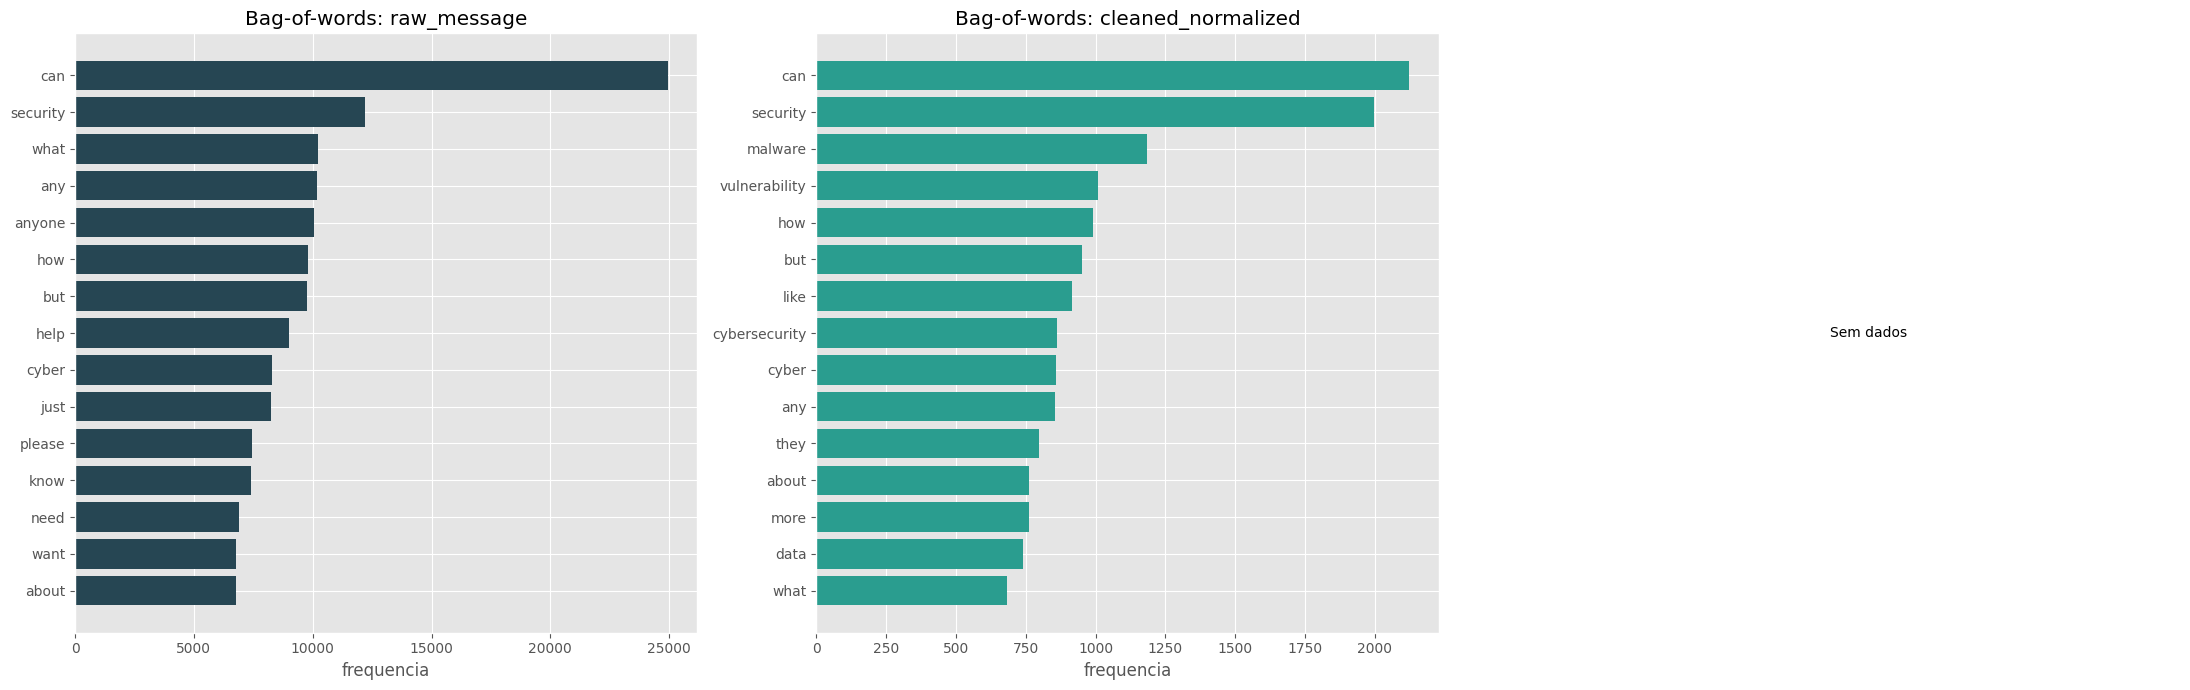

In [6]:
bow_inputs = [
    ("raw_message", raw_df["message"] if not raw_df.empty else pd.Series(dtype=str)),
    ("cleaned_normalized", clean_df["cleaning_normalized_message"] if not clean_df.empty else pd.Series(dtype=str)),
    ("llm_cleaned_text", classified_df["classification_cleaned_text"] if not classified_df.empty else pd.Series(dtype=str)),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
bow_tables = []
bow_colors = {
    "raw_message": "#264653",
    "cleaned_normalized": "#2a9d8f",
    "llm_cleaned_text": "#e76f51",
}

for ax, (label, series) in zip(axes, bow_inputs):
    top_df = top_terms(series, top_n=TOP_N_WORDS)
    if top_df.empty:
        ax.text(0.5, 0.5, "Sem dados", ha="center", va="center")
        ax.set_axis_off()
        continue
    chart_df = top_df.sort_values("count")
    ax.barh(chart_df["term"], chart_df["count"], color=bow_colors[label])
    ax.set_title(f"Bag-of-words: {label}")
    ax.set_xlabel("frequencia")
    bow_tables.append(top_df.assign(stage=label))

plt.tight_layout()

display(pd.concat(bow_tables, ignore_index=True) if bow_tables else pd.DataFrame(columns=["term", "count", "stage"]))


In [7]:
if classified_df.empty:
    print("Nenhum arquivo classificado pela LLM foi encontrado em sentinel_replica_jsons_classified_eval/.")
else:
    classification_overview = pd.DataFrame(
        [
            {"metric": "posts_classified", "value": int(len(classified_df))},
            {"metric": "files_classified", "value": int(classified_df["source_file"].nunique())},
            {
                "metric": "pct_cyber_relevant",
                "value": round(100 * classified_df["classification_is_cyber_relevant"].fillna(False).mean(), 2),
            },
            {
                "metric": "pct_requires_human_review",
                "value": round(100 * classified_df["classification_requires_human_review"].fillna(False).mean(), 2),
            },
            {
                "metric": "pct_ioc_present",
                "value": round(100 * classified_df["classification_ioc_present"].fillna(False).mean(), 2),
            },
        ]
    )
    display(classification_overview)

    threat_counts = classified_df["classification_threat_label"].value_counts()
    severity_counts = classified_df["classification_severity"].value_counts()
    confidence_counts = classified_df["classification_confidence"].value_counts()
    language_counts = classified_df["classification_language"].value_counts()
    target_counts = classified_df["classification_target_type"].value_counts()
    quality_counts = classified_df["classification_content_quality"].value_counts()
    secondary_counts = explode_counts(classified_df, "classification_secondary_labels").head(15)
    ioc_counts = explode_counts(classified_df, "classification_ioc_types")
    severity_confidence = pd.crosstab(
        classified_df["classification_severity"],
        classified_df["classification_confidence"],
    ).reindex(index=["informational", "low", "medium", "high", "critical"], columns=["low", "medium", "high"], fill_value=0)

    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    plot_count_series(axes[0, 0], threat_counts, "Distribuicao de threat_label", color="#264653")
    plot_count_series(axes[0, 1], severity_counts, "Distribuicao de severidade", color="#e76f51")
    plot_count_series(axes[0, 2], confidence_counts, "Distribuicao de confianca", color="#2a9d8f")
    plot_count_series(axes[1, 0], language_counts, "Idiomas detectados", color="#457b9d")
    plot_count_series(axes[1, 1], target_counts, "Tipos de alvo", color="#6d597a")
    plot_count_series(axes[1, 2], quality_counts, "Qualidade de conteudo", color="#f4a261")
    plt.tight_layout()

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    plot_heatmap(axes[0], severity_confidence, "Severidade x confianca")
    plot_count_series(
        axes[1],
        secondary_counts.set_index("label")["count"] if not secondary_counts.empty else pd.Series(dtype=int),
        "Top secondary_labels",
        color="#8ecae6",
    )
    plot_count_series(
        axes[2],
        ioc_counts.set_index("label")["count"] if not ioc_counts.empty else pd.Series(dtype=int),
        "IOC types",
        color="#ffb703",
    )
    plt.tight_layout()

    review_columns = [
        "source_file",
        "id",
        "classification_threat_label",
        "classification_severity",
        "classification_confidence",
        "classification_requires_human_review",
        "classification_rationale",
        "message",
    ]
    review_df = classified_df.loc[classified_df["classification_requires_human_review"].fillna(False), review_columns].head(15)
    display(review_df)


Nenhum arquivo classificado pela LLM foi encontrado em sentinel_replica_jsons_classified_eval/.


## Distribuicao temporal de reports (campo `date`)

Analise da quantidade de reports ao longo do tempo, com agregacao diaria e mensal.

,stage,date_day,report_count
0,raw,2023-01-01,247
1,raw,2023-01-02,77
2,raw,2023-01-03,51
3,raw,2023-01-04,123
4,raw,2023-01-05,92
5,raw,2023-01-06,121
6,raw,2023-01-07,229
7,raw,2023-01-08,94
8,raw,2023-01-09,93
9,raw,2023-01-10,79


,stage,date_month,report_count
0,raw,2023-01-01,3405
1,raw,2023-02-01,2304
2,raw,2023-03-01,4351
3,raw,2023-04-01,4943
4,raw,2023-05-01,5009
5,raw,2023-06-01,7734
6,raw,2023-07-01,9708
7,raw,2023-08-01,8803
8,raw,2023-09-01,8917
9,raw,2023-10-01,4589


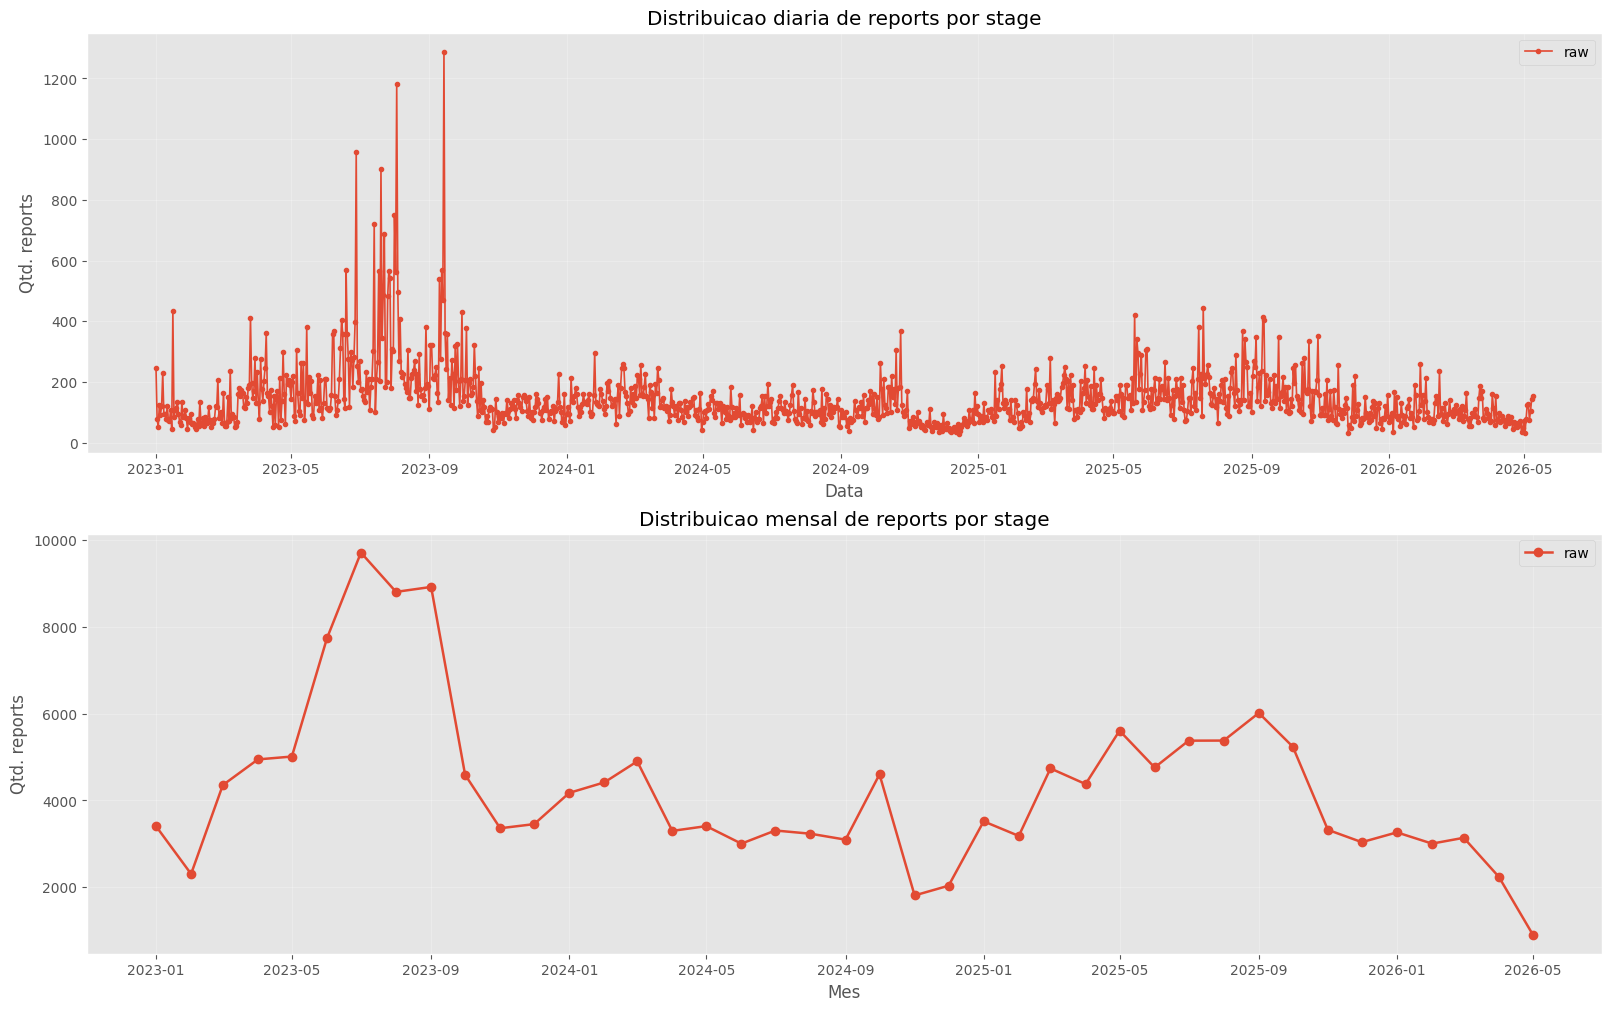

,min_date,max_date,total_reports
stage,,,
raw,2023-01-01,2026-05-09,174901


<Figure size 640x480 with 0 Axes>

In [ ]:
# Distribuicao de reports por data usando o campo `date`

def _build_date_frame(df: pd.DataFrame, stage_name: str) -> pd.DataFrame:
    if df.empty or "date" not in df.columns:
        return pd.DataFrame(columns=["date", "stage"])

    out = df[["date"]].copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce", utc=True).dt.tz_convert(None)
    out = out.dropna(subset=["date"])
    out["stage"] = stage_name
    return out


date_frames = [
    _build_date_frame(raw_df, "raw"),
    #_build_date_frame(clean_df, "cleaned"),
    #_build_date_frame(classified_df, "classified"),
]

date_df = pd.concat(date_frames, ignore_index=True)

if date_df.empty:
    print("Nenhum valor valido encontrado no campo 'date'.")
else:
    # Contagem diaria
    date_df["date_day"] = date_df["date"].dt.date
    daily_counts = (
        date_df.groupby(["stage", "date_day"]).size().reset_index(name="report_count")
    )

    # Contagem mensal (mais estavel para visualizacao)
    date_df["date_month"] = date_df["date"].dt.to_period("M").dt.to_timestamp()
    monthly_counts = (
        date_df.groupby(["stage", "date_month"]).size().reset_index(name="report_count")
    )

    display(
        daily_counts.sort_values(["stage", "date_day"]).head(20),
        monthly_counts.sort_values(["stage", "date_month"]).head(20),
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

    for stage_name, group in daily_counts.groupby("stage"):
        series = group.sort_values("date_day")
        axes[0].plot(series["date_day"], series["report_count"], marker=".", linewidth=1.2, label=stage_name)

    axes[0].set_title("Distribuicao diaria de reports por stage")
    axes[0].set_xlabel("Data")
    axes[0].set_ylabel("Qtd. reports")
    # axes[0].set_yscale("log")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    for stage_name, group in monthly_counts.groupby("stage"):
        series = group.sort_values("date_month")
        axes[1].plot(series["date_month"], series["report_count"], marker="o", linewidth=1.8, label=stage_name)

    axes[1].set_title("Distribuicao mensal de reports por stage")
    axes[1].set_xlabel("Mes")
    axes[1].set_ylabel("Qtd. reports")
    # axes[1].set_yscale("log")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.show()

    date_summary = (
        date_df.groupby("stage")["date"]
        .agg(min_date="min", max_date="max", total_reports="count")
        .sort_values("total_reports", ascending=False)
    )
    display(date_summary)